# Visualizing AWGN: The Physics of the Channel Layer

In deep learning, we usually pass tensors perfectly from one layer to the next. In Semantic Communication, we inject an entire physical environment (a **Channel**) directly into the middle of our neural network.

In this notebook, we use the `AWGNChannel` PyTorch module we just built in Step 1.3 to visualize what different **Signal-to-Noise Ratio (SNR)** levels physically do to a mathematical waveform.

In [5]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath('..'))
from src.channel import AWGNChannel

print("Loaded")

Loaded


### Step 1: Generating a Base Signal
To make the distortion easy to see, we will simulate a clean, continuous sine wave instead of a complex semantic vector.

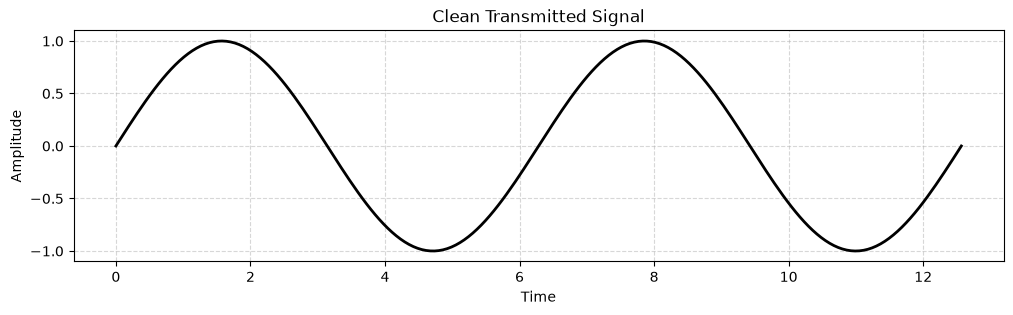

In [6]:

time_steps = torch.linspace(0, 4 * np.pi, 200)
clean_signal = torch.sin(time_steps)

plt.figure(figsize=(12, 3))
plt.plot(time_steps.numpy(), clean_signal.numpy(), color='black', linewidth=2)
plt.title("Clean Transmitted Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Step 2: Simulating the Physical Channel at Different SNR Levels
We will pass our clean wave through our PyTorch `AWGNChannel` at four different SNR levels:
- **20 dB:** A very clear connection.
- **10 dB:** A standard, slightly noisy connection.
- **0 dB:** Signal power and noise power are exactly equal.
- **-5 dB:** The noise is significantly louder than the signal.

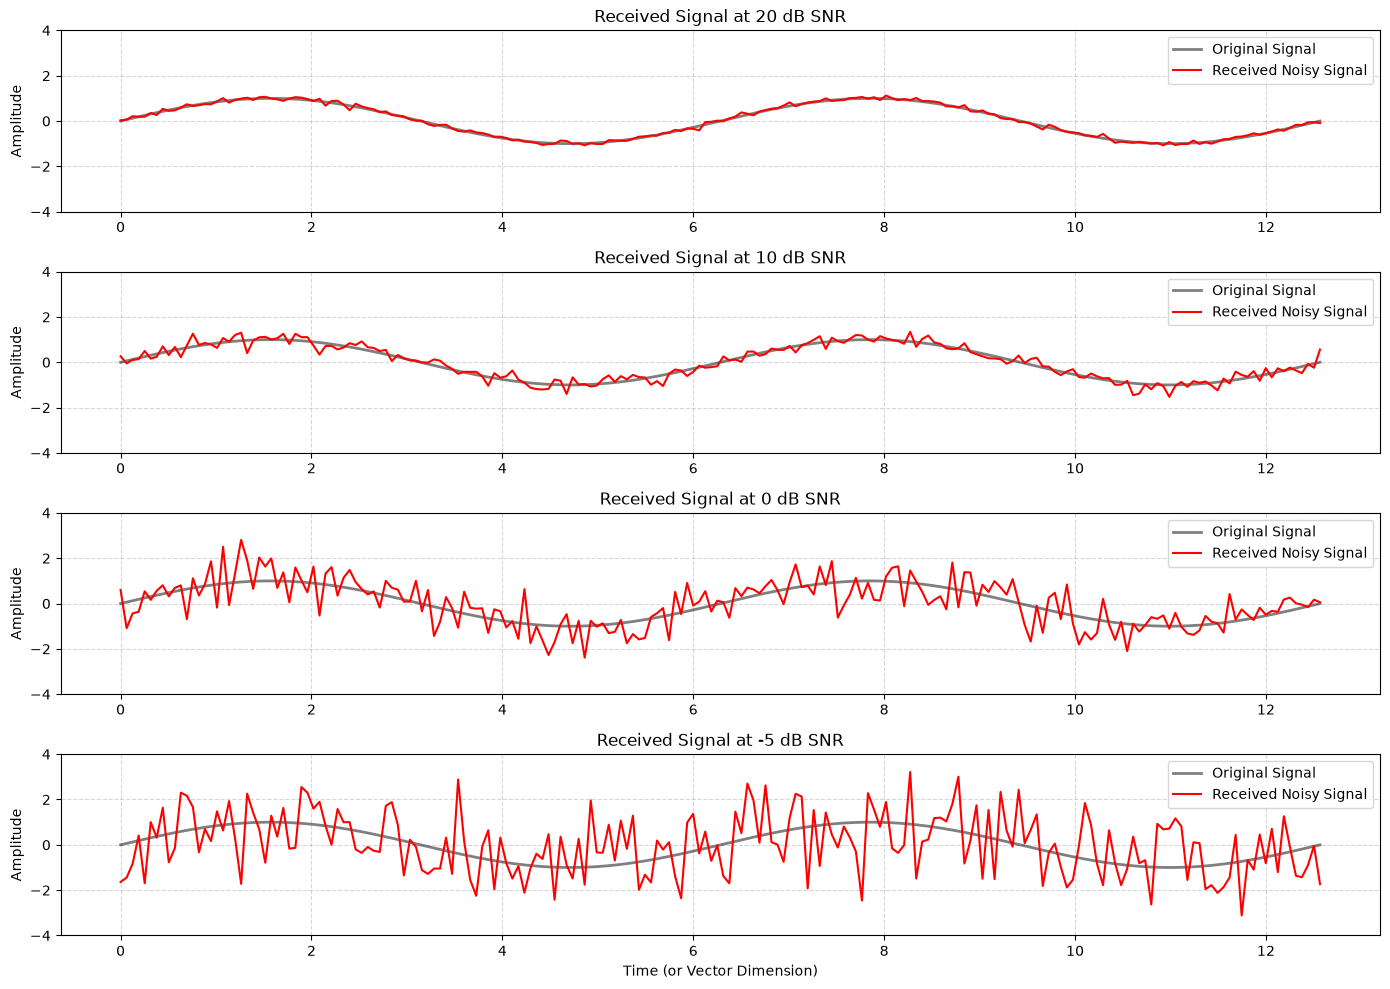

In [7]:
snr_levels = [20, 10, 0, -5]
channel = AWGNChannel()

plt.figure(figsize=(14, 10))

for i, snr in enumerate(snr_levels):
    
    received_signal = channel(clean_signal, snr_db_override=snr)
    
    plt.subplot(4, 1, i+1)
    plt.plot(time_steps.numpy(), clean_signal.numpy(), color='black', linewidth=2, label='Original Signal', alpha=0.5)
    plt.plot(time_steps.numpy(), received_signal.numpy(), color='red', linewidth=1.5, label='Received Noisy Signal')
    
    plt.title(f"Received Signal at {snr} dB SNR")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.ylim(-4, 4)

plt.xlabel("Time (or Vector Dimension)")
plt.tight_layout()
plt.show()

### Conclusion
Looking at the **-5 dB** graph, the original sine wave structure is almost entirely invisible to the human eye. 

---
### Step 3: Visualizing SNR in Latent Vector Space
While waveforms are easy to look at, our Neural Network actually transmits data as multi-dimensional mathematical vectors. 

Let's visualize a simple 2-Dimensional vector space. We will transmit a single clean vector (representing our "Semantic Meaning"), and then plot 500 noisy received samples around it at different SNR level

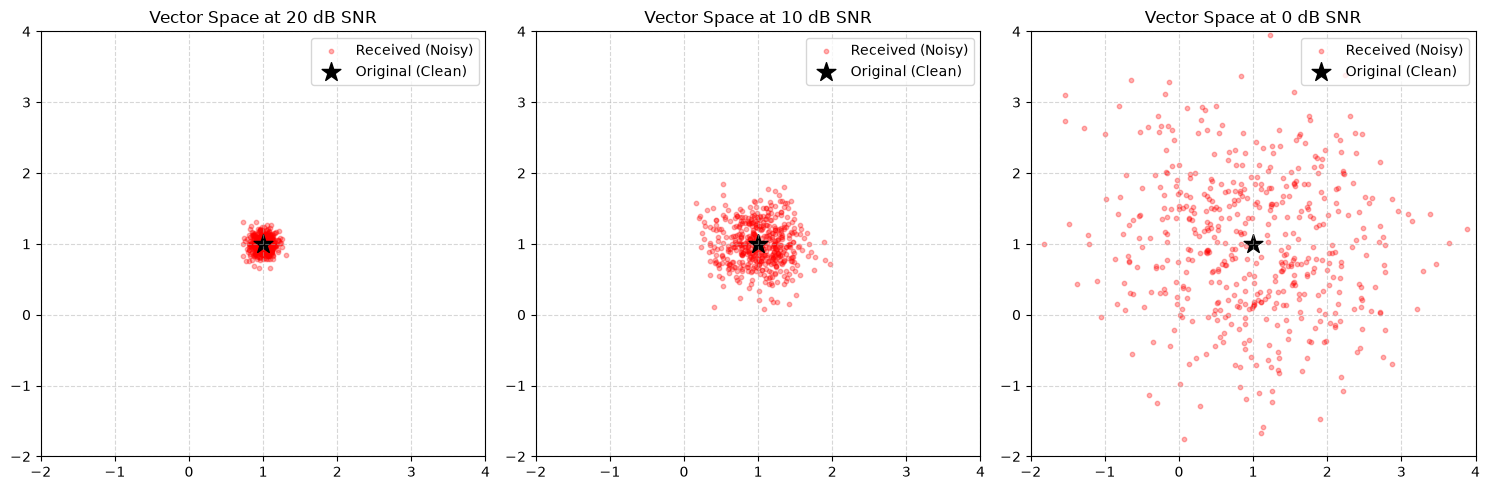

In [8]:
clean_vector = torch.tensor([[1.0, 1.0]])
num_samples = 500

plt.figure(figsize=(15, 5))

for i, snr in enumerate([20, 10, 0]):
    plt.subplot(1, 3, i+1)
    
    #pass 500 times trhough the channel
    noisy_samples = []
    for _ in range(num_samples):
        noisy_samples.append(channel(clean_vector, snr_db_override=snr).numpy())
    noisy_samples = np.vstack(noisy_samples)
    
    #noise cloud plot
    plt.scatter(noisy_samples[:, 0], noisy_samples[:, 1], color='red', alpha=0.3, s=10, label='Received (Noisy)')
    
    #original vector
    plt.scatter(clean_vector[:, 0], clean_vector[:, 1], color='black', marker='*', s=200, label='Original (Clean)')
    
    plt.title(f"Vector Space at {snr} dB SNR")
    plt.xlim(-2, 4)
    plt.ylim(-2, 4)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()